### relationship bettween lake level change and precipitation. 
chenghai: r(0.47), p(0.07)    
dianchi: r(-0.55), p(0.04)    
erhai: r(-0.07), p(0.85)    
fuxian: r(-0.11), p(0.68)      
lugu: r(0.13), p(0.623)     
qilu: r(-0.18), p(0.49).  
xingyun: r(-0.2), p(0.43)     
yangzonghai: r(-0.24), p(0.36)     
yilong: r(-0.46), p(0.1) 


In [6]:
import pandas as pd 
import seaborn as sns
from scipy.stats import pearsonr
from utils.date_transform import decimal_to_date


In [7]:
def read2month_csv(path_lake_wse, var_name='lake_wse'):
    '''    
    (1) read pixc/lakesp/icesat2 data and convert to dataframe
    (2) convert decimal date to monthly date
    '''
    lake_wse = pd.read_csv(path_lake_wse)
    lake_wse['date'] = lake_wse['date'].apply(decimal_to_date)  
    lake_wse['date'] = pd.to_datetime(lake_wse['date'])
    lake_wse['year_month'] = lake_wse['date'].dt.to_period('M') 
    lake_wse_month = lake_wse.groupby('year_month')[var_name].mean().reset_index()    
    # lake_wse_month = lake_wse_month.set_index('year_month')     
    return lake_wse_month



In [8]:
## lake name:  chenghai, dianchi, erhai, fuxian,  
## lugu, qilu, xingyun, yangzonghai, yilong  
lake_name = 'dianchi'   


In [9]:
# precipitation data
path_precip_lake = f'data/climate/{lake_name}_era5_monthly_precipitation.csv'
path_wse_lake = f'data/swot_l2/pixc/{lake_name}-lake/{lake_name}_pixc_wse.csv'
## water level data
path_wse_lake = f'data/swot_l2/pixc/{lake_name}-lake/{lake_name}_pixc_wse.csv'



In [10]:
lake_precip = pd.read_csv(path_precip_lake).rename(columns={'Date': 'year_month', 'total_precipitation_sum': 'precipitation'})
lake_precip['year_month'] = pd.to_datetime(lake_precip['year_month']).dt.to_period('M')
lake_wse_monthly = read2month_csv(path_wse_lake, var_name='height_weighted_mean') 
lake_wse_monthly = read2month_csv(path_wse_lake, var_name='height_weighted_mean')


TimeoutError: [Errno 60] Operation timed out

In [ ]:
lake_wse_precipt = lake_wse_monthly.merge(lake_precip, on='year_month', how='left') 
lake_wse_precipt['height_weighted_mean_anomly'] = lake_wse_precipt['height_weighted_mean'] - lake_wse_precipt['height_weighted_mean'].mean()
lake_wse_precipt['precipitation_anomly'] = lake_wse_precipt['precipitation'] - lake_wse_precipt['precipitation'].mean()



<Axes: xlabel='year_month', ylabel='height_weighted_mean_anomly'>

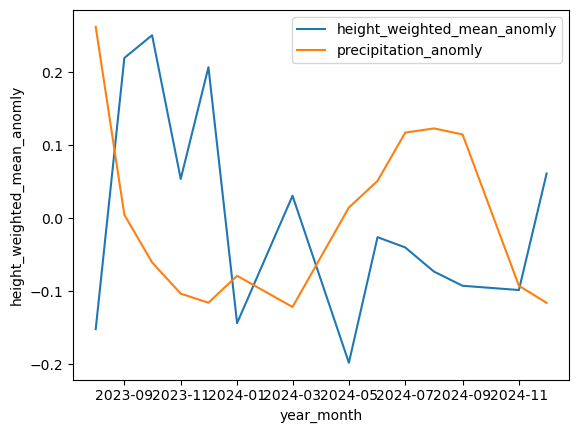

In [ ]:
import matplotlib.pyplot as plt
df = lake_wse_precipt.copy()
df['year_month'] = df['year_month'].dt.to_timestamp()
sns.lineplot(data=df, x='year_month', y='height_weighted_mean_anomly', label='height_weighted_mean_anomly')
sns.lineplot(data=df, x='year_month', y='precipitation_anomly', label='precipitation_anomly')


In [ ]:
r, p_value = pearsonr(lake_wse_precipt['height_weighted_mean_anomly'], 
                      lake_wse_precipt['precipitation_anomly'])

print(f"Pearson 相关系数 (r): {r}")
print(f"P 值 (p-value): {p_value}")


Pearson 相关系数 (r): -0.4587472512009183
P 值 (p-value): 0.09896041415042202


#### comparison bettwen dry season (11-4) wet season (5-10).
lake level:     
chenghai: wet(0.015 m), dry(-0.801 m), dif: 0.816 m      
dianchi:  wet(-0.218 m), dry(0.001 m), dif: -0.219 m         
erhai:    wet(-0.109 m),  dry(0.117 m), dif: -0.226 m      
fuxian:   wet(-1.261 m), dry(0.286 m), dif: -1.547 m   
lugu:     wet(-0.070 m), dry(-0.790 m), dif: 0.72 m       
qilu:     wet(-0.508 m), dry(-0.451 m), dif: -0.057 m        
xingyun:  wet(-0.297 m), dry(-0.251 m), dif: -0.046 m     
yangzonghai: wet(-0.121 m), dry(0.673 m), dif: -0.794 m       
yilong:   wet(-0.429 m), dry(0.148 m), dif: -0.577 m    


In [ ]:
## select data from 2023-11 to 2024-04
wet_season_wse = lake_wse_precipt[
    lake_wse_precipt['year_month'].between(pd.Period('2024-05', freq='M'),
                                           pd.Period('2024-10', freq='M'))].copy()

dry_season_wse = lake_wse_precipt[
    lake_wse_precipt['year_month'].between(pd.Period('2023-11', freq='M'),
                                           pd.Period('2024-04', freq='M'))].copy()

wet_season_wse_sum = wet_season_wse['height_weighted_mean_anomly'].sum()
dry_season_wse_sum = dry_season_wse['height_weighted_mean_anomly'].sum() 
print(f"wet season WSE sum: {wet_season_wse_sum}")
print(f"dry season WSE sum: {dry_season_wse_sum}")



wet season WSE sum: -0.42896071428572213
dry season WSE sum: 0.14777142857155923


### percipitation:    
chenghai: wet(1005.7 mm), dry(79.9 mm)           
dianchi:  wet(771.5 mm), dry(131.9 mm)       
erhai:    wet(454 mm), dry(122.8 mm)     
fuxian:   wet(1053.7 mm), dry(123.7 mm)     
lugu:     wet(1466.5 mm), dry(118.5 mm)    
qilu:     wet(942.6 mm), dry(101.7 mm)    
xingyun:  wet(1041.3 mm), dry(114.0 mm)    
yangzonghai: wet(932.6 mm), dry(128.3 mm)    
yilong:   wet(1068.2 mm), dry(99.1 mm) 


In [ ]:
## select data from 2023-11 to 2024-04
wet_season = lake_wse_precipt[
    lake_wse_precipt['year_month'].between(pd.Period('2024-05', freq='M'),
                                           pd.Period('2024-10', freq='M'))].copy()

dry_season = lake_wse_precipt[
    lake_wse_precipt['year_month'].between(pd.Period('2023-11', freq='M'),
                                           pd.Period('2024-04', freq='M'))].copy()

wet_season_percip = wet_season['precipitation'].sum()
dry_season_percip = dry_season['precipitation'].sum() 
print(f"wet season precipitation: {wet_season_percip}")
print(f"dry season precipitation: {dry_season_percip}")


wet season precipitation: 1.068204988544993
dry season precipitation: 0.0991201256819832
